In [19]:
# Import required libraries
# import xarray as xr
# %load_ext cudf.pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.express as px


from matplotlib.ticker import MultipleLocator, LogLocator, AutoMinorLocator, FixedLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from matplotlib import gridspec
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, lognorm
import numpy as np
from statistics import geometric_mean
from scipy.optimize import curve_fit



In [20]:
def make_hist_dfs_AFS(df_raw, **kwargs):
    plt.rcParams.update({'font.size': 15, 'font.family': 'DejaVu Sans'})

    # read kwargs for Y axis key (default to 'rup_force' if not provided)
    y_key = kwargs.pop('y_key', 'force_clean')
    x_ticks = kwargs.pop('x_ticks', [0, 20, 40, 60, 80, 100])

    df_raw.dropna(subset=['log_lr_bin'], inplace=True)
    N_bins = len(df_raw['log_lr_bin'].unique())
    if N_bins == 7:
        N_plot = N_bins+1
    else:
        N_plot = N_bins

    row, columns = compute_grid(N_plot)
    fig, axes = plt.subplots(
        row, columns, figsize=(columns*4, row*4), sharex=True)
    # Plot each histogram
    # fig.suptitle("rupture force histograms SA-B ",fontsize =10)
    ax_liner_arr = axes.flatten()
    temp_gauss = []
    temp_bimod = []
    df_afs_avg = pd.DataFrame()

    average_rup_afs_hist = np.zeros(N_bins)
    average_ldr_afs_hist = np.zeros(N_bins)
    std_ldr_afs_hist = np.zeros(N_bins)
    std_upper_lr = np.zeros(N_bins)
    std_lower_lr = np.zeros(N_bins)
    std_rup_afs_hist = np.zeros(N_bins)
    mode_rup_afs_hist = np.zeros(N_bins)
    sem_rup_afs_hist = np.zeros(N_bins)
    sem_ldr_afs_hist = np.zeros(N_bins)
    std_bimodal_rup_force = np.zeros(N_bins)
    sem_bimodal_rup_force = np.zeros(N_bins)

    avg_bi_modal = np.zeros(N_bins)

    avg_gauss_arr = np.zeros(N_bins)
    std_gauss_arr = np.zeros(N_bins)
    sem_gauss_arr = np.zeros(N_bins)

    for name, df_bin in df_raw.groupby(by='log_lr_bin'):
        print(int(name)-1)
        i = int(name)

        if i < len(ax_liner_arr):

            ax = ax_liner_arr[i]
            ldr_temp = geometric_mean(df_bin['velocity_calc'])
            mantissa, exponent = f"{ldr_temp:.1e}".split("e")
            latex_formatted = f"${mantissa} \\times 10^{{{int(exponent)}}}$ µm/s"

            # ax.hist(df_bin['rup_force'],**kwargs)

            ax.set_title(latex_formatted, fontsize=20)
            total_freq = len(df_bin[y_key])
            n, bins, patches = ax.hist(
                df_bin[y_key], label=f'size = {total_freq}', **kwargs)
            bins_ft = (bins[1:]+bins[:-1])/2  # for len(x)==len(y)

            # ax.legend(frameon=False,fontsize = 15)
            ax.legend(handlelength=0, handletextpad=0.0, frameon=False)
            xmin, xmax = plt.xlim()
            xmax = 60
            xmin, xmax = -2, 120
            mu, std = norm.fit(df_bin[y_key])

            mode_index = n.argmax()
            modal_force = (bins[mode_index] + bins[mode_index+1])/2
            print(f'the mode froce :{modal_force}')

            x_p = np.linspace(xmin, xmax, 100)
            p = norm.pdf(x_p, mu, std)

            # ax.plot(x_p, p, 'k',color = 'black', linewidth=2)
            # #ax.set_xlim(-10,80)
            # ax.axvline(mu,color= 'black')
            temp_gauss.append(mu)

            try:
                p0_gauss = [
                    0.5*np.mean(df_bin[y_key]), 0.5*np.std(df_bin[y_key]), max(n)]

                popt, pcov = curve_fit(gauss, bins_ft, n, p0=p0_gauss, bounds=([0, 0, 0], [
                                       120, 20, 2*max(n)]))  # <--- leave out the first estimation of the parameters

                x_p = np.linspace(-10, xmax, 120)

                expected = (mu, std, 10, 2*std, 10)
                bounds = (0, [1000, 1000, 1000, 1000, 1000])
                expected = (0.5*mu, std, 1, std, 0)
                bounds = (0, [100, 100, 20, 200, 100])
                expected = (0.5*mu, std, max(n), std, min(n))
                bounds = (0, [100, 100, 2*max(n), 200, 2*max(n)])

                params, cov = curve_fit(
                    bimodal, bins_ft, n, expected, bounds=bounds)
                # ax.plot(x_p, bimodal(x_p, *params), color='red',linestyle= '--',alpha = 1, lw=3.5,zorder=1)
                # ax.axvline(params[0],color = 'red')

                ax.plot(x_p, gauss(x_p, *popt), color='tab:blue',
                        linestyle='--', linewidth=2)
                ax.set_xlim(xmin, 120)
                ax.axvline(popt[0], color='tab:blue')

                # Make x-axis markers more visible
                ax.xaxis.set_major_locator(MultipleLocator(20))  # Major ticks every 20 units
                ax.xaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 10 units

                # Enhance tick appearance
                ax.tick_params(axis='x', which='major', labelsize=14,
                              length=8, width=2, color='black', labelcolor='black')
                ax.tick_params(axis='x', which='minor',
                              length=4, width=1, color='black')

                # Make y-axis ticks more visible too
                ax.tick_params(axis='y', which='major', labelsize=14,
                              length=8, width=2, color='black', labelcolor='black')

                # Add grid for better readability
                ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
                ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.5)

                # Set specific x-axis tick positions for better visibility
                ax.set_xticks(x_ticks)

                # ...and individual Gauss curves
                gauss_1_params = params[:3]
                gauss_2_params = [2*params[0], params[3], params[4]]
                temp_bimod.append(params[0])

                avg_bi_modal[i] = params[0]
                std_bimodal_rup_force[i] = params[1]
                sem_bimodal_rup_force[i] = params[1] / \
                    np.sqrt(len(df_bin['velocity_calc']))

                avg_gauss_arr[i] = popt[0]
                std_gauss_arr[i] = popt[1]
                sem_gauss_arr[i] = popt[1]/np.sqrt(len(df_bin['velocity_calc']))

            except RuntimeError:
                print(f'didnt work: {name}')
                avg_bi_modal[i] = mu
                std_bimodal_rup_force[i] = std
                sem_bimodal_rup_force[i] = std

            # Add axis labels to bottom row only
            if i >= (row-1) * columns:  # Bottom row
                ax.set_xlabel("Tether Force (pN)", fontsize=16, fontweight='bold')
            if i % columns == 0:  # Left column
                ax.set_ylabel("Density", fontsize=16, fontweight='bold')

        # Geometric mean and geometric SD
        log_data = np.log(df_bin['velocity_calc'].to_numpy())
        log_mean = log_data.mean()
        log_std = log_data.std()
        geo_mean = np.exp(log_mean)
        average_ldr_afs_hist[i] = geo_mean
        std_lower_lr[i] = geo_mean - np.exp(log_mean - log_std)
        std_upper_lr[i] = np.exp(log_mean + log_std) - geo_mean

        average_rup_afs_hist[i] = popt[0]

        std_rup_afs_hist[i] = popt[1]
        sem_rup_afs_hist[i] = popt[1]/np.sqrt(len(df_bin['velocity_calc']))
        std_ldr_afs_hist[i] = np.std(np.log(df_bin['velocity_calc']))
        sem_ldr_afs_hist[i] = std_ldr_afs_hist[i]/np.sqrt(len((df_bin['velocity_calc'])))
        mode_rup_afs_hist[i] = modal_force
    # Adjust layout
    plt.tight_layout()
    # plt.show()

    temp_afs_avg_dict = {'rup_force': average_rup_afs_hist[:], 'avg_LDR': average_ldr_afs_hist[:], 'LDR': average_ldr_afs_hist[:],
                         'std_rup_force': std_rup_afs_hist, 'sem_rup_force': sem_rup_afs_hist,
                         'STD_LDR': std_ldr_afs_hist, 'sem_LDR': sem_ldr_afs_hist,
                         'bi_modal': avg_bi_modal, 'std_bimodal': std_bimodal_rup_force, 'sem_bi_modal': sem_bimodal_rup_force, 'avg_gauss': avg_gauss_arr, 'std_gauss': std_gauss_arr, 'sem_gauss': sem_gauss_arr,
                         'ldr_upper': std_upper_lr, 'ldr_lower': std_lower_lr}

    df_afs_avg = pd.DataFrame(temp_afs_avg_dict)
    return fig, df_afs_avg

def compute_grid(n):
    # Find the factors of n
    factors = [(i, n // i)
               for i in range(1, int(math.sqrt(n)) + 1) if n % i == 0]
    # Pick the factor pair with the smallest difference (to make the grid as square as possible)
    rows, cols = min(factors, key=lambda x: abs(x[0] - x[1]))
    return rows, cols

def gauss(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

    # return A*np.exp(-(x-mu)**2/(2*sigma**2))
# TODO get the mean from the a initial gaussian fit and then use it a inital parameter for the bimodel fit

def bimodal(x, mu1, sigma1, A1, sigma2, A2):
    return gauss(x, mu1, sigma1, A1)+gauss(x, 2*mu1, sigma2, A2)

In [21]:
def safe_log10(data):
    """Compute log10 safely, avoiding -inf from zeros or negatives."""
    data = np.array(data, dtype=float)
    data[data <= 0] = np.nan
    return np.log10(data)

# Publication-style settings
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.edgecolor': 'black',
})

### I. Mount the data from the google drive.
- if user does not have acces, the csv file needs to be uploaded
- if user has access, run code below directly



In [22]:
# from google.colab import drive
# drive.mount('/content/drive')

In [23]:
# open csv file as dataframe
# IMPORTANT: Update this path to the actual location of your CSV file in Google Drive
csv_file_path = '/Users/evillz/Data/article/final_yey/w_felix/batch_analysis_results/detailed_plateau_data.csv'
# csv_file_path = '/content/drive/MyDrive/TetherAnalysis/detailed_plateau_data.csv'

df = pd.read_csv(csv_file_path)

In [24]:
svg_file_path = '/Users/evillz/Data/article/final_yey/w_felix/batch_analysis_results/detailed_plateau_data.svg'

II. The list of tether events starts from the last index until 0. The last index refers to the last plateau/tether identified in the curve.

To adjust the amount of tethers analyzed within the datarame, Increase

> N = # of tethers to analyze



In [25]:
# Cycle through file_idx and plateau_idx, get delta_avg for selected plateaus
# Set N to control how many of the last plateaus to analyze per file
N =1  # Change this value to get the last N plateaus
N_end_offset = 0
N_start_offset = 1


selected_delta_avg = []
unselected_delta_avg = []
selected_velocity_calc = []
selected_velocity_meta = []
unselected_velocity_meta = []
selected_delta_time = []
selected_slope= []
selected_tether_lifetime_m = []
selected_tether_lifetime_s = []
loading_rate = []
rupture_slope_arr = []
# Group by file_idx to process each file
for file_idx in df['file_idx'].unique():
    file_data = df[df['file_idx'] == file_idx]
    filename = file_data['filename'].iloc[0]  # Get filename for this file_idx

    # print(f"\nFile {file_idx}: {filename}")

    # Get unique plateau indices and sort them to get the last N
    plateau_indices = sorted(file_data['plateau_idx'].unique())
    num_plateaus = len(plateau_indices)

    # if num_plateaus == 6:
    #     print ('yes')

    if num_plateaus-1 <= 1:
        num_plateaus = 0
    else:
        num_plateaus = num_plateaus - N - 1  # Adjust for start offset

    # last_n_plateaus = plateau_indices[-N-1:-N] if len(plateau_indices) >= N else plateau_indices
    last_n_plateaus = plateau_indices[:num_plateaus:-1]

    # print(f"  Total plateaus: {len(plateau_indices)}, analyzing last {len(last_n_plateaus)} plateaus: {last_n_plateaus}")

    # Cycle through only the last N plateaus in this file
    for plateau_idx in last_n_plateaus:
        plateau_data = file_data[file_data['plateau_idx'] == plateau_idx]

        if len(plateau_data) > 0:
            row = plateau_data.iloc[0]  # Get the plateau data
            delta_avg = row['delta_avg'] # tether force
            plateau_selected = row['plateau_selected']
            plateau_delta_time = row['delta_time'] # time for tethering to occur starting from contact point
            plateau_loading_rate = row['mean dN/dt']  #mean derivate dF/dZ
            plateau_velocity_calc = row['plateau_velocity_calc']  # calculated velocity
            # meta_velocity = int(np.round(row['velocity_metadata']))
            plateau_velocity_meta = int(np.round(row['velocity_metadata'])) # metadata velocity1
            plateau_velocity_calc = plateau_velocity_meta if plateau_velocity_calc == np.nan or 0 else plateau_velocity_calc # calculated velocity
            plateau_slope = row['slope']  # Slope of plateau
            plateau_avg_idx = row['plateau_avg']  # index of plateau average value within the plateau
            tether_lifeime_s = row['tether_lifetime_s']  # duration of a plateau in seconds
            rupture_slope = row['rupture_slope']  # Slope of rupture segment

            # print(f"  Plateau {plateau_idx}: delta_avg={delta_avg:.2e}, selected={plateau_selected}, \
            #         delta_time={plateau_delta_time:.2f}, mean_derivative={plateau_loading_rate:.2e}, \
            #         velocity_calc={plateau_velocity_calc:.2e}, velocity_meta={plateau_velocity_meta}")

            # Store delta_avg and velocity_metadata based on selection status
            if plateau_selected:
                # store items back into dataframe
                # Removed redundant df.loc assignments for speed optimization
                # df.loc[plateau_data.index, 'selected_delta_avg'] = delta_avg
                # df.loc[plateau_data.index, 'selected_velocity_meta'] = np.abs(plateau_velocity_meta)
                # df.loc[plateau_data.index, 'selected_delta_time'] = plateau_delta_time
                # df.loc[plateau_data.index, 'selected_slope'] = plateau_slope
                # df.loc[plateau_data.index, 'selected_tether_lifetime_m'] = row['tether_lifetime_m']
                # df.loc[plateau_data.index, 'selected_tether_lifetime_s'] = tether_lifeime_s
                # df.loc[plateau_data.index, 'loading_rate'] = plateau_loading_rate
                # df.loc[plateau_data.index, 'rupture_slope'] = rupture_slope

                # Create lists for selected values
                # Append NaN if any value is exactly zero, else append the value
                selected_delta_avg.append(np.nan if delta_avg == 0 else delta_avg) #Delta F of average force of plateau
                selected_velocity_calc.append(np.nan if plateau_velocity_calc == 0 else np.abs(plateau_velocity_calc)) # velocity at plteau make positive since its retract
                selected_velocity_meta.append(np.nan if plateau_velocity_meta == 0 else np.abs(plateau_velocity_meta)) # velocity at plteau make positive since its retract
                selected_delta_time.append(np.nan if plateau_delta_time == 0 else plateau_delta_time) # time of each plateau
                selected_slope.append(np.nan if plateau_slope == 0 else plateau_slope) #slope of plateau segment df/dz
                selected_tether_lifetime_m.append(np.nan if row['tether_lifetime_m'] == 0 else row['tether_lifetime_m']) # Detachment tie
                selected_tether_lifetime_s.append(np.nan if tether_lifeime_s == 0 else tether_lifeime_s) #time of each tether plateau from contact point
                loading_rate.append(np.nan if plateau_loading_rate == 0 else plateau_loading_rate)
                rupture_slope_arr.append(np.nan if rupture_slope == 0 else rupture_slope)
            else:
                unselected_delta_avg.append(delta_avg)
                unselected_velocity_meta.append(plateau_velocity_meta)

## II. Variable Summary

| Variable Name                | Description                                                                                 | Units                |
|------------------------------|--------------------------------------------------------------------------------------------|----------------------|
| `selected_delta_avg`         | List of average tether force values for selected plateaus                                  | Newtons (N)          |
| `selected_velocity_meta`     | List of velocity metadata values for selected plateaus                                     | µm/s                 |
| `selected_delta_time`        | List of plateau segment duration                                                           | seconds (s)          |
| `selected_slope`             | List of plateau slopes (dF/dZ) for selected plateaus                                       | N/m                  |
| `selected_tether_lifetime_m` | List of detachment distances for selected plateaus                                         | meters (m)           |
| `selected_tether_lifetime_s` | List of tether lifetimes for selected plateaus                                             | seconds (s)          |
| `loading_rate`               | loading rates (mean dF/dt) for selected plt where df=force (N),dt = dt*velocity_um_s       | N/s                  |
| `rupture_slope_arr`          | List of rupture slopes for selected plateaus                                               | N/m                  |
| `velocity_meta_clean`        | Numpy array of selected velocities, cleaned of NaN and zero values                        | µm/s                 |
| `delta_avg_clean`            | Numpy array of selected average forces, cleaned of NaN and zero values                    | Newtons (N)          |
| `force_valid_mask`           | Boolean mask for valid force/velocity data (non-NaN, non-zero, within force range)         | -                    |
| `velocity_force_filtered`    | Filtered velocities after applying `force_valid_mask`                                      | µm/s                 |
| `force_filtered`             | Filtered forces after applying `force_valid_mask`                                          | Newtons (N)          |
| `velocity_log`               | Log10 of filtered velocities                                                               | log10(µm/s)          |
| `force_log`                  | Filtered forces converted to pN                                                            | pN                   |
| `finite_mask`                | Boolean mask for finite log values                                                         | -                    |
| `velocity_log_clean`         | Cleaned log10 velocities (finite only)                                                     | log10(µm/s)          |
| `force_log_clean`            | Cleaned force values in pN (finite only)                                                   | pN                   |
| `force_df`                   | DataFrame containing filtered and cleaned velocity and force data                          | -                    |
| `means_df`                   | DataFrame containing mean force and velocity per velocity bin                              | -                    |
| `tether_force_array`         | Absolute value of selected delta_avg as numpy array                                        | Newtons (N)          |
| `tether_lifetime_s_array`    | Numpy array of selected tether lifetimes (seconds)                                         | seconds (s)          |
| `tether_lifetime_m_array`    | Numpy array of selected detachment distances (meters)                                      | meters (m)           |
| `loading_rate_array`         | Numpy array of loading rates                                                               | N/s                  |
| `tether_force_bin_labels_for_points` | List of force bin labels for each point (for binned plotting)                      | pN                   |
| `loading_rate_bin_labels_for_points` | List of loading rate bin labels for each point (for binned plotting)               | pN/s                 |

#III. Sanity - check for negative values in the in tether lifetime meters and seconds. IF yes, there is an issue with the *analysis*

In [26]:
# Check for negative values in selected_distance_detachment
has_negative = any(val < 0 for val in selected_tether_lifetime_m and selected_tether_lifetime_s)
print("Contains negative values:", has_negative)

Contains negative values: True


# IV. Filter and prepare force data.

- add the necessary filter within

> valid_mask

- create dataframe "force_df" containing filtered force data



In [27]:
# Filter and prepare force data
velocity_meta_clean = np.array(selected_velocity_meta)
velocity_calc_clean = np.array(selected_velocity_calc)
delta_avg_clean = np.array(selected_delta_avg)
slope_clean = np.array(selected_slope) * 1e6  # Convert to dN/dµm
lifetime_m_clean = np.array(selected_tether_lifetime_m)
lifetime_s_clean = np.array(selected_tether_lifetime_s)
delta_time = np.array(selected_delta_time)  

valid_mask = (
    ~np.isnan(velocity_meta_clean) &
    # ~np.isnan(slope_clean) &
    ~np.isnan(delta_avg_clean) &
    ~np.isnan(lifetime_m_clean) &
    ~np.isnan(lifetime_s_clean) &

    (velocity_meta_clean > 1e-6) &
    (delta_avg_clean != 0) &
    (np.abs(delta_avg_clean) > 10e-12) &   # >10 pN
    (np.abs(delta_avg_clean) < 100e-12) &      # <1000 pN
    (lifetime_m_clean > 0) &
    (lifetime_s_clean > 0)
    # (slope_clean != 0) &
    # (slope_clean < 1e-6 ) &
    # (slope_clean < -1)

)

velocity_meta_filtered = velocity_meta_clean[valid_mask]
velocity_calc_filtered = velocity_calc_clean[valid_mask]
force_filtered = delta_avg_clean[valid_mask]
slope_filtered = slope_clean[valid_mask]
tether_lifetime_m_filtered = lifetime_m_clean[valid_mask]
tether_lifetime_s_filtered = lifetime_s_clean[valid_mask]
delta_time_filtered = delta_time[valid_mask]

# Convert to log scale for analysis
velocity_meta_log = safe_log10(velocity_meta_filtered)
velocity_calc_log = safe_log10(velocity_calc_filtered)
lifetime_m_log = safe_log10(tether_lifetime_m_filtered)
lifetime_s_log = safe_log10(tether_lifetime_s_filtered)
delta_time_log = safe_log10(delta_time_filtered)
# slope_log = safe_log10(slope_filtered)
force_clean = np.abs(force_filtered) * 1e12 # change to pN

# Remove infinite values
finite_mask = np.isfinite(velocity_meta_log) & np.isfinite(force_clean) & np.isfinite(velocity_calc_log) & np.isfinite(slope_filtered)
print('of infinite values:', len(velocity_meta_log) - len(finite_mask))

# apply finite_mask
velocity_meta_log_clean = velocity_meta_log[finite_mask]
velocity_calc_log_clean = velocity_calc_log[finite_mask]
force_clean = force_clean[finite_mask]
velocity_clean = velocity_meta_filtered[finite_mask]
velocity_calc_clean = velocity_calc_filtered[finite_mask]
slope_filtered_clean = slope_filtered[finite_mask]
lifetime_m_log_clean = lifetime_m_log[finite_mask]
lifetime_s_log_clean = lifetime_s_log[finite_mask]
lifetime_m_clean = tether_lifetime_m_filtered[finite_mask]
lifetime_s_clean = tether_lifetime_s_filtered[finite_mask]
delta_time_log_clean = delta_time_log[finite_mask]
delta_time_clean = delta_time_filtered[finite_mask]



# Create DataFrame for analysis
force_df = pd.DataFrame({
    'velocity_meta': velocity_clean,
    'velocity_calc': velocity_calc_clean,
    'velocity_meta_log': velocity_meta_log_clean,
    'velocity_calc_log': velocity_calc_log_clean,
    'force_clean': force_clean,
    'slope': slope_filtered_clean,
    'lifetime_m_log': lifetime_m_log_clean,
    'lifetime_s_log': lifetime_s_log_clean,
    'lifetime_m_clean': lifetime_m_clean,
    'lifetime_s_clean': lifetime_s_clean,
    'delta_time': delta_time_clean,
})


of infinite values: 0


Text(0.5, 1.0, 'Comparison of Velocity Metadata and Calculated Velocity')

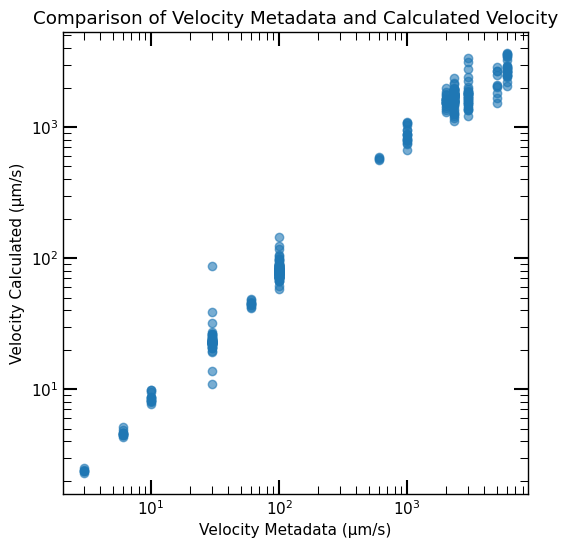

In [28]:
# compare corresponding velocity meta and velocity calc
plt.figure(figsize=(6,6))
plt.scatter(force_df['velocity_meta'], force_df['velocity_calc'], alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Velocity Metadata (µm/s)')
plt.ylabel('Velocity Calculated (µm/s)')
plt.title('Comparison of Velocity Metadata and Calculated Velocity')       

#V. Create Velocity bins

In [29]:
velocity_bin_edges = np.array([1, 3, 6, 15, 30, 200, 10000])

force_df['log_LR'] = np.log(force_df['velocity_calc'])
print ()
N_bins_afs = 6
bin_label_afs = []
for i in range(N_bins_afs):

    bin_label_afs.append(f"{i}")  # = ['1','2','3','4','5','6','7']

# print (bin_label_afs)

# Binning is here
force_df["log_lr_bin"] = pd.cut(
    force_df['log_LR'], bins=np.log(velocity_bin_edges), labels=bin_label_afs)

# velocity_bin_edges=np.exp(velocity_bin_edges_log)
print(f'{velocity_bin_edges} µm/s')

binwidth_afs = 15
bins_afs = range(-10, 120, binwidth_afs)


# print (force_df["log_lr_bin"])


[    1     3     6    15    30   200 10000] µm/s


-1
the mode froce :27.5
0
the mode froce :27.5
1
the mode froce :42.5
2
the mode froce :42.5
3
the mode froce :57.5
4
the mode froce :57.5


/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_74459/3152259188.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, df_bin in df_raw.groupby(by='log_lr_bin'):


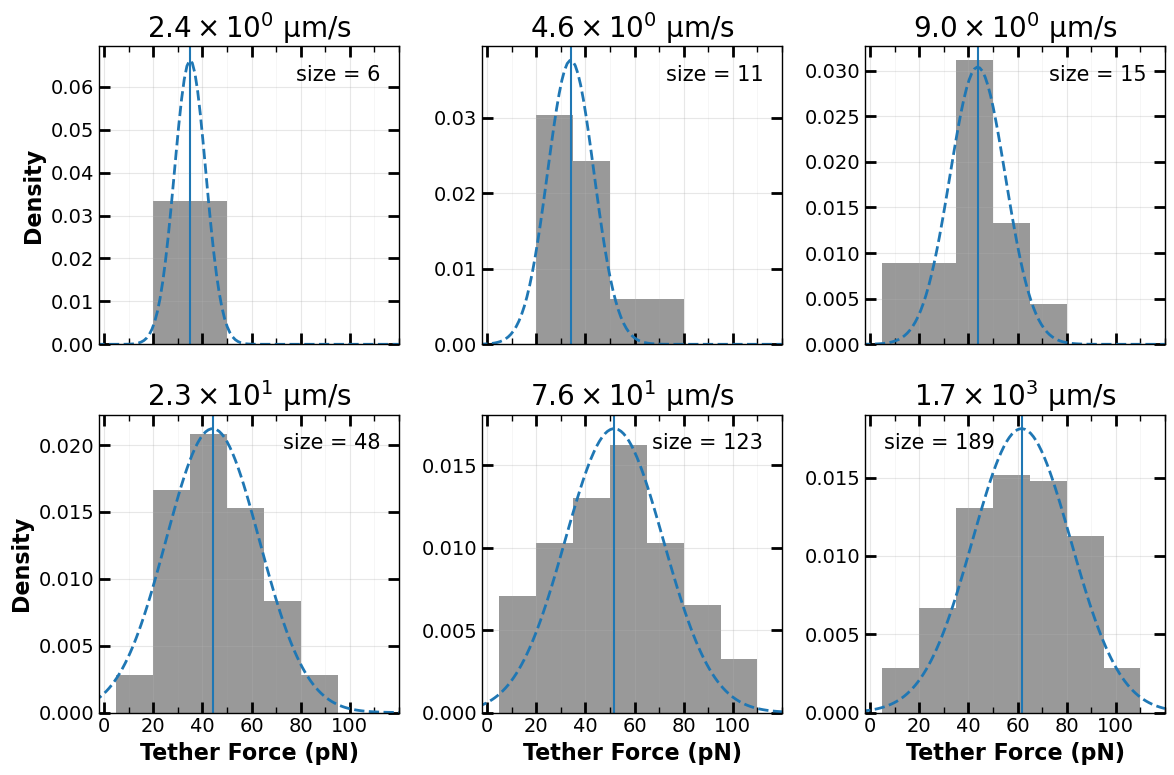

In [30]:
# Define kwargs for customization
plot_kwargs = {
    'color': 'grey',
    'alpha': 0.8,
    'density': True,
    'bins': bins_afs, 
    'y_key': 'force_clean'

}
fig_dist_afs, df_afs_avg = make_hist_dfs_AFS(force_df, **plot_kwargs)
plt.show()




In [31]:
svg_file_path = '/Users/evillz/Data/article/'

# save histogram as svg
fig_dist_afs.savefig(svg_file_path + 'tether_extraction_force_distribution.svg', dpi=300, bbox_inches='tight')   

Y-axis range: 11.2 to 99.8 pN


<Figure size 1050x750 with 0 Axes>

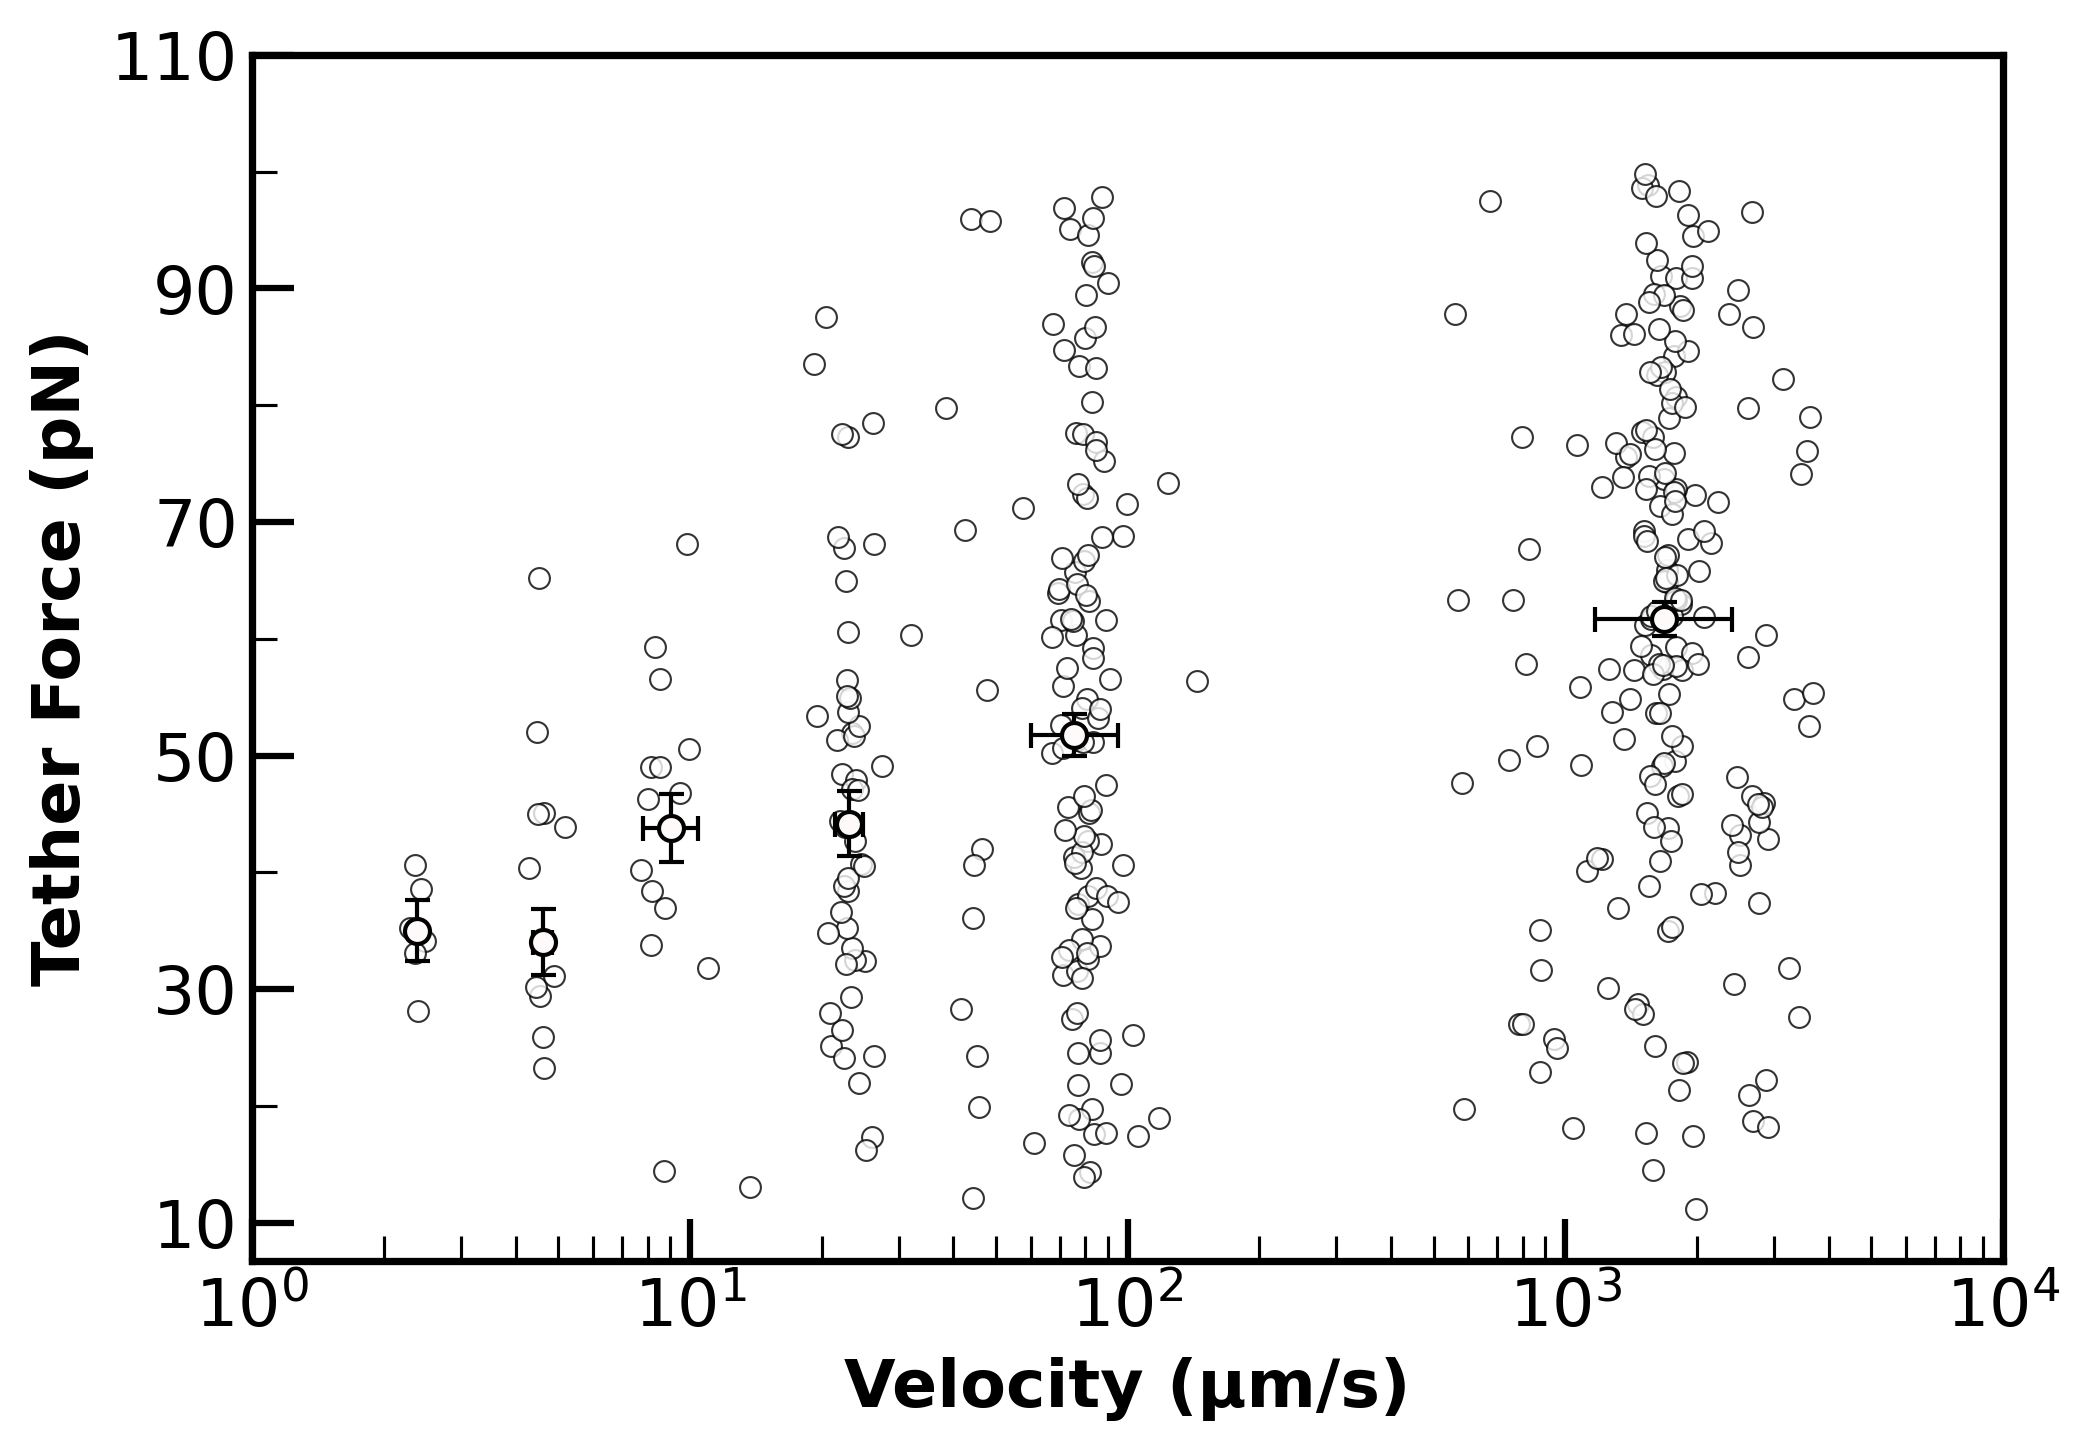

Total selected tether plateaus analyzed: 392


In [32]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import os
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.figure(figsize=(7, 5), dpi=150)
plt.rcParams.update({
    'axes.linewidth': 1.75,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 10,  # Length of major ticks
    "ytick.major.size": 10,

    "xtick.minor.size": 6,  # Length of minor ticks
    "ytick.minor.size": 6,

    "xtick.major.width": 1.5,  # Width of major ticks
    "ytick.major.width": 1.5,

    "xtick.minor.width": 0.75,  # Width of minor ticks
    "ytick.minor.width": 0.75,
    "xtick.top": False,  # Enable top ticks
    "ytick.right": False,  # Enable right ticks
    # "ytick.left": True
})

# Main plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(force_df['velocity_calc'], force_df['force_clean'],
          alpha=0.8, s=25, color='white', edgecolors='black', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')

error_afs = ax.errorbar(df_afs_avg['avg_LDR'], df_afs_avg['avg_gauss'], yerr=df_afs_avg['sem_gauss'],
                         xerr=[df_afs_avg['ldr_lower'], df_afs_avg['ldr_upper']], label=' ', elinewidth=1, fmt='o', markersize=6, capsize=3, zorder=20, color='black', markerfacecolor='snow')


# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xscale('log')

plt.tight_layout()
plt.xlim(left = 10e-1)
ax.set_xlabel("Velocity (µm/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xlim(1,10000)

# Fix y-axis tick labels
ax.tick_params(axis='x', labelsize=16, which='both', labelbottom=True)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=16, which='both', labelleft=True, labelcolor='black', color='black')  # Y-axis tick labels

# Set y-axis ticks based on your data range
y_min = force_df['force_clean'].min()
y_max = force_df['force_clean'].max()
print(f"Y-axis range: {y_min:.1f} to {y_max:.1f} pN")

# Create nice y-axis tick values
y_ticks = [10,30,50,70,90,110]  # X MAJOR TICKS
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{tick:.0f}' for tick in y_ticks])
ax.yaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 2 units

# Ensure y-axis is visible
ax.yaxis.set_visible(True)
ax.spines['left'].set_visible(True)

plt.show()

#print how many samples
print(f"Total selected tether plateaus analyzed: {len(force_df)}")

In [33]:
# Comprehensive Model Comparison: Theoretical vs Empirical Fits
# Based on Equation 17: F³ - Ff₀² = (2π)³2c²vₓLc ln(R/r₁) rewrite it as v(F)= (F³ - Ff₀²)/l_0

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import pandas as pd
from sklearn.metrics import r2_score

# Prepare data (change velocity by force and viceversa, use mean velocity)
y_data = df_afs_avg['avg_LDR'].values  # velocity (μm/s)
x_data = df_afs_avg['avg_gauss'].values  # force (pN)
x_errors = df_afs_avg['sem_gauss'].values # Force errors

print("=== THEORETICAL MODEL ANALYSIS ===")
print(f"Data points for fitting: {len(x_data)}")
print(f"Velocity range: {y_data.min():.1f} to {y_data.max():.1f} μm/s")
print(f"Force range: {x_data.min():.1f} to {x_data.max():.1f} pN")
print()

# =================================================================
# MODEL 0: Theoretical Model (Based on Eq. 17)
# Simplified form: v = (F^3 +F*f0^2)/l0
# Based on Equation 17: F³ - Ff₀² = (2π)³2c²vₓLc ln(R/r₁) rewrite it as v(F)= (F³ - Ff₀²)/l_0
# # =================================================================

def Brochard_model(F, f0, l0):
    """
    Theoretical logarithmic model based on Eq. 17
    v = (F^3 +F*f0^2)/l0
    where f0 ~ f₀ (static force)
    and l0 ~ (2π)³2c²vₓLc (material/geometric parameters)
    """
    velocity = (F**3 - F*f0**2) / l0
    return velocity
    #return (F**3 - F*f0) / l0


models = {
      'Brochard ': {
      'func': Brochard_model,
      'initial_guess': [2000, 100],
      'bounds' : ([0,1e5],[500,1e12]),
      'color': 'purple',
      'linewidth': 2,
      'theory': False
  }
}

# Fit all models
results = {}
x_smooth = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 200)

for name, model_info in models.items():
    try:
        # Fit the model
        popt, pcov = curve_fit(
            model_info['func'],
            x_data,
            y_data,
            p0=model_info['initial_guess'],
            sigma=x_errors,
            absolute_sigma=True,
            maxfev=5000
        )
        print (popt)

        # Calculate fit statistics
        y_pred = model_info['func'](x_data, *popt)
        y_smooth = model_info['func'](x_smooth, *popt)

        # R² score
        r2 = r2_score(y_data, y_pred)

        # Reduced χ²
        chi2_red = np.sum(((y_data - y_pred) / x_errors)**2) / (len(y_data) - len(popt))

        # AIC and BIC
        n = len(y_data)
        k = len(popt)
        mse = np.mean((y_data - y_pred)**2)
        aic = n * np.log(mse) + 2 * k
        bic = n * np.log(mse) + k * np.log(n)

        # Parameter uncertainties
        param_errors = np.sqrt(np.diag(pcov))

        results[name] = {
            'params': popt,
            'param_errors': param_errors,
            'y_pred': y_pred,
            'y_smooth': y_smooth,
            'r2': r2,
            'chi2_red': chi2_red,
            'aic': aic,
            'bic': bic,
            'mse': mse,
            'success': True
        }

    except Exception as e:
        print(f"Failed to fit {name}: {e}")
        results[name] = {'success': False}

print("=== FITTING RESULTS ===")
print(f"{'Model':<25} {'R²':<8} {'χ²_red':<8} {'AIC':<8} {'BIC':<8} {'MSE':<8}")
print("-" * 75)

successful_models = {}
for name, result in results.items():
    if result['success']:
        successful_models[name] = result
        print(f"{name:<25} {result['r2']:<8.4f} {result['chi2_red']:<8.3f} "
              f"{result['aic']:<8.1f} {result['bic']:<8.1f} {result['mse']:<8.3f}")

=== THEORETICAL MODEL ANALYSIS ===
Data points for fitting: 6
Velocity range: 2.4 to 1677.7 μm/s
Force range: 34.0 to 61.7 pN

[43.69285977 75.93591078]
=== FITTING RESULTS ===
Model                     R²       χ²_red   AIC      BIC      MSE     
---------------------------------------------------------------------------
Brochard                  0.8086   25021.874 71.2     70.8     72892.884


In [34]:
popt, pcov = curve_fit(
    Brochard_model,
    x_data,
    y_data,
    p0=model_info['initial_guess'],
)

print (popt)

[41.81493914 88.94738515]


Y-axis range: 11.2 to 99.8 pN


<Figure size 2100x1500 with 0 Axes>

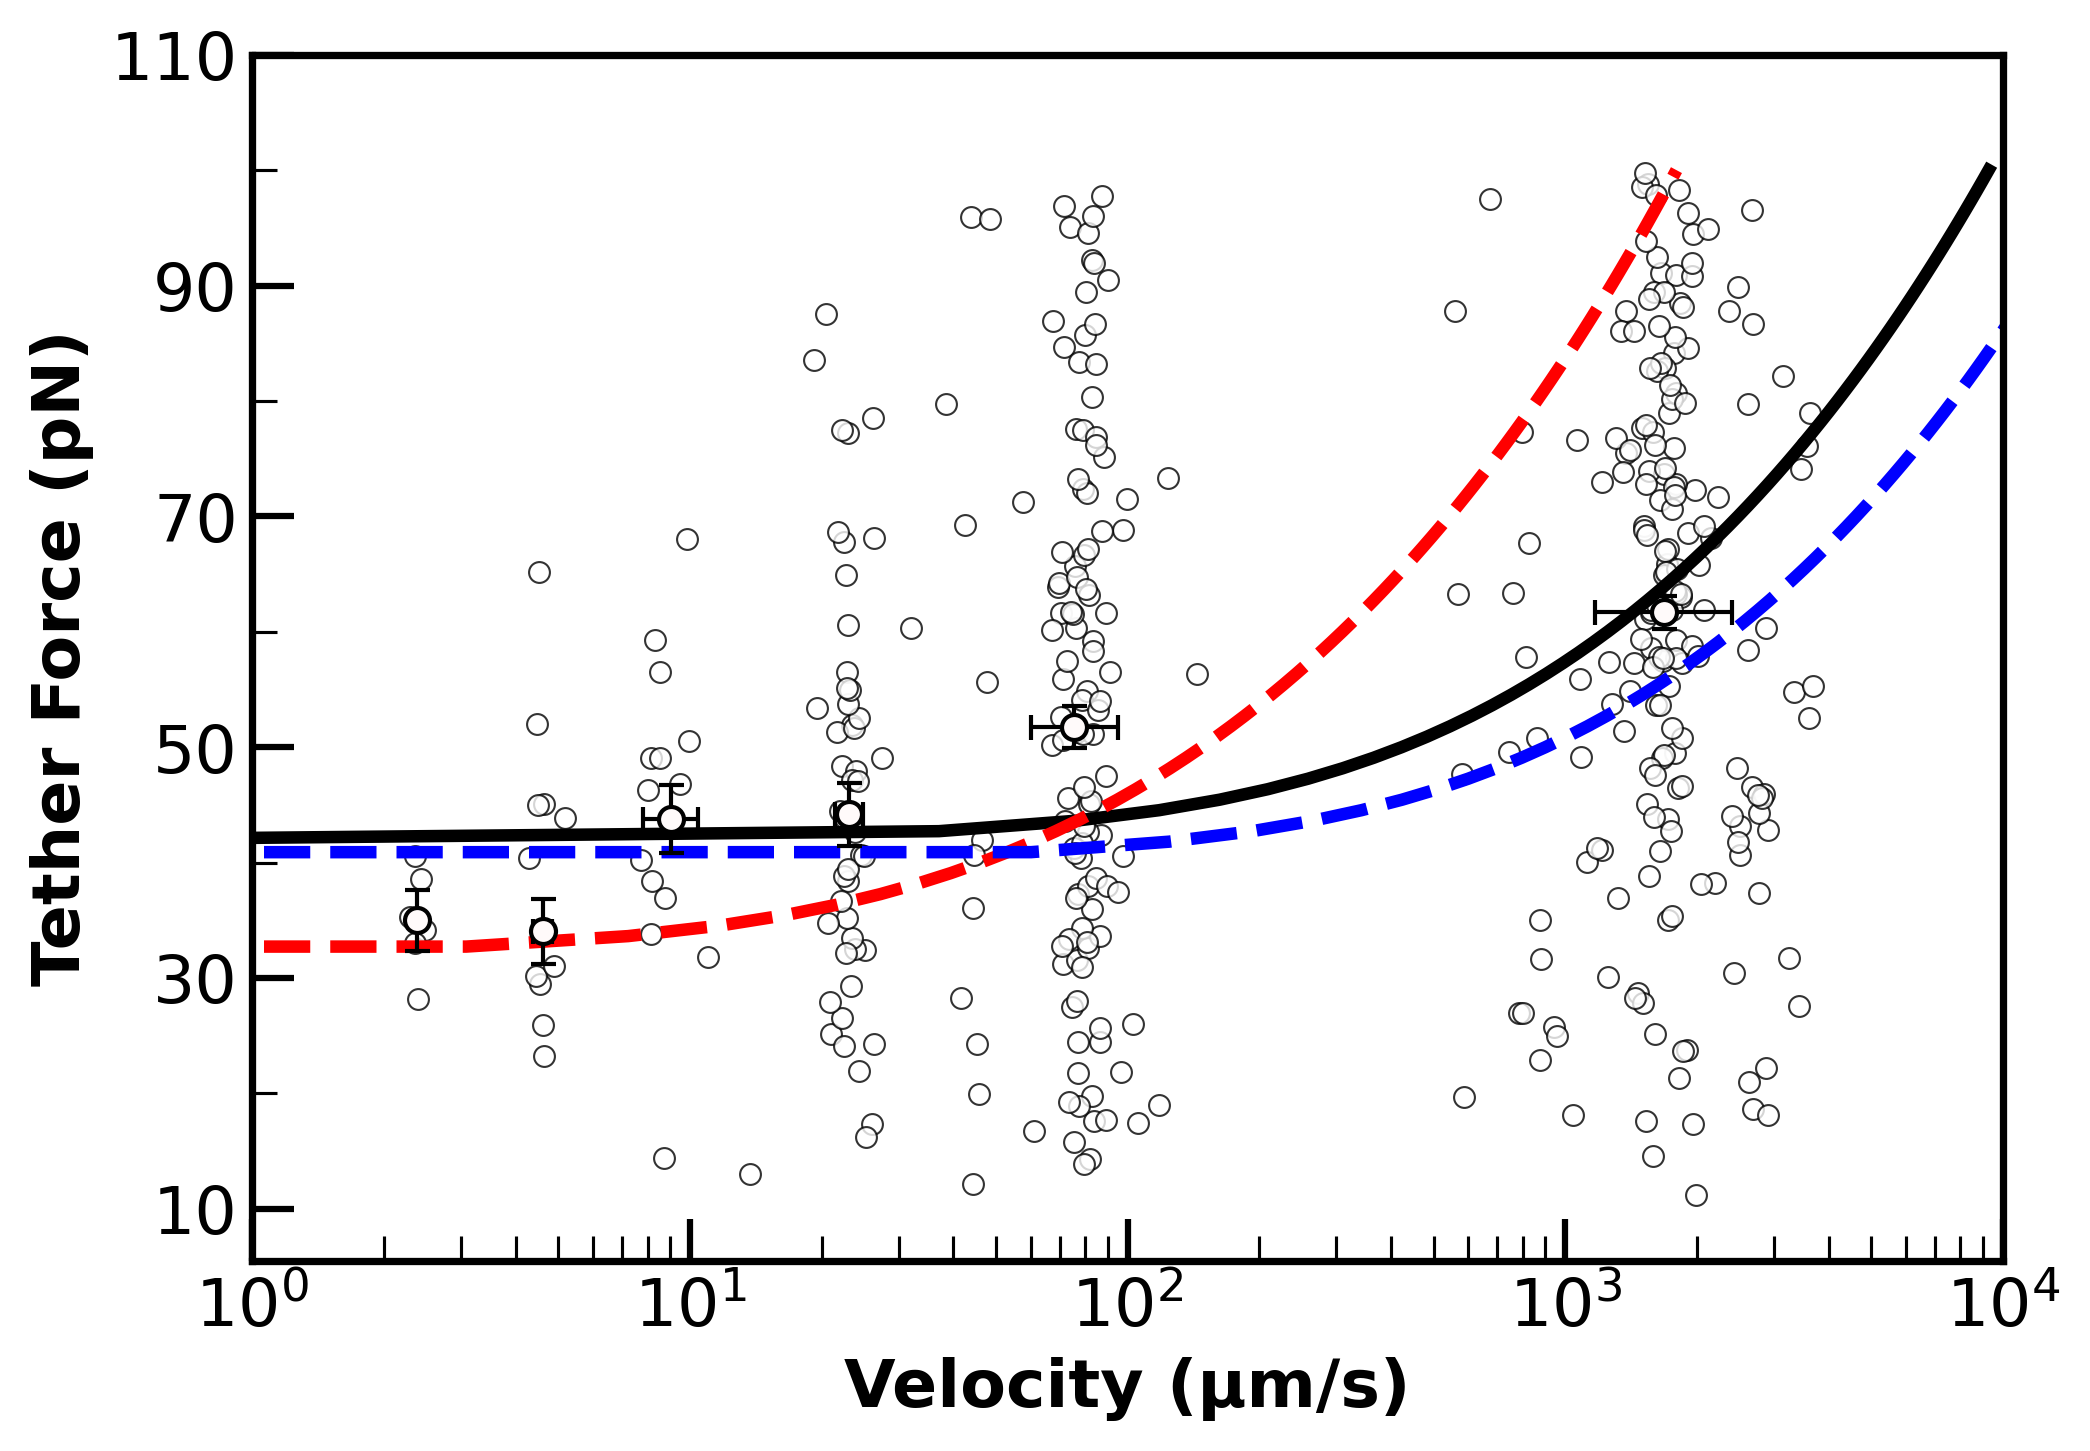

Total selected tether plateaus analyzed: 392


In [35]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import os
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.figure(figsize=(7, 5), dpi=300)
plt.rcParams.update({
    'axes.linewidth': 1.75,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 10,  # Length of major ticks
    "ytick.major.size": 10,

    "xtick.minor.size": 6,  # Length of minor ticks
    "ytick.minor.size": 6,

    "xtick.major.width": 1.5,  # Width of major ticks
    "ytick.major.width": 1.5,

    "xtick.minor.width": 0.75,  # Width of minor ticks
    "ytick.minor.width": 0.75,
    "xtick.top": False,  # Enable top ticks
    "ytick.right": False,  # Enable right ticks
    # "ytick.left": True
})

# Main plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(force_df['velocity_calc'], force_df['force_clean'],
          alpha=0.8, s=25, color='white', edgecolors='black', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')

error_afs = ax.errorbar(df_afs_avg['avg_LDR'], df_afs_avg['avg_gauss'], yerr=df_afs_avg['sem_gauss'],
                         xerr=[df_afs_avg['ldr_lower'], df_afs_avg['ldr_upper']], label=' ', elinewidth=1, fmt='o', markersize=6, capsize=3, zorder=20, color='black', markerfacecolor='snow')
force_plot = np.linspace(10,100,100)
popt_test=[32, 500]
popt_test_2 = [40, 50]
ax.plot(Brochard_model(force_plot,*popt),force_plot, color='Black', linewidth = 3)
ax.plot(Brochard_model(force_plot,*popt_test),force_plot, color='red', linestyle='--', linewidth = 3)
ax.plot(Brochard_model(force_plot,*popt_test_2),force_plot, color='blue', linestyle='--', linewidth = 3)
# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xscale('log')

plt.tight_layout()
plt.xlim(left = 10e-1)
ax.set_xlabel("Velocity (µm/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xlim(1,10000)

# Fix y-axis tick labels
ax.tick_params(axis='x', labelsize=16, which='both', labelbottom=True)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=16, which='both', labelleft=True, labelcolor='black', color='black')  # Y-axis tick labels

# Set y-axis ticks based on your data range
y_min = force_df['force_clean'].min()
y_max = force_df['force_clean'].max()
print(f"Y-axis range: {y_min:.1f} to {y_max:.1f} pN")

# Create nice y-axis tick values
y_ticks = [10,30,50,70,90,110]  # X MAJOR TICKS
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{tick:.0f}' for tick in y_ticks])
ax.yaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 2 units

# Ensure y-axis is visible
ax.yaxis.set_visible(True)
ax.spines['left'].set_visible(True)

plt.show()

#print how many samples
print(f"Total selected tether plateaus analyzed: {len(force_df)}")